# P8: Prediction

Turn a CPP **signature** into a working, interpretable predictor. The core case is **binary classification** (two labelled sets in, a model that tells you *why* out); the same pipeline then extends to **multi-class** and **regression** by transforming the labels, with no change to CPP. This protocol chains the standard AAanalysis pipeline end-to-end (split each sequence into *parts*, mine a *CPP signature*, assemble a numeric *feature matrix*, and fit a `TreeModel`) into a glass-box predictor whose every input is a human-readable `PART-SPLIT-SCALE` feature id tied to an AAontology physicochemical property.

It is the direct successor to **P1: CPP signature**: Protocol 1 *discovers* the determinants that distinguish a **test group** (`label=1`) from a **reference group** (`label=0`); here we *use* that signature to predict, and rank the features by how hard the model leans on them.

Interpretable features first, then the *simplest* model that does the job. Because every CPP feature is a named physicochemical property at a named sequence location, a plain tree ensemble on top of them is already a glass box, and you only believe it once it clearly **beats a trivial baseline**.

**When to use it.** Reach for this protocol when you have **two labelled sets of sequences** and want a model that not only predicts a new protein but names the physicochemistry behind the call. In glossary terms you are moving from **determinant discovery** (Protocol 1) to **prediction** (here, binary classification) with a `TreeModel` riding on interpretable CPP features instead of a black box.

We work at the **domain level** (dataset prefix `DOM_`): the **unit of comparison** is the transmembrane-domain (TMD) part set, CPP's native ground. The biological question: *given a transmembrane protein, is it a γ-secretase (GSEC) substrate, and which properties of its TMD and juxtamembrane (JMD) flanks drive that call?* Because every feature is a position-resolved physicochemical property (an AAontology scale evaluated at a part and split), the fitted importances **name the determinants**: they are not anonymous weights.

**When *not* to use it.**

- If you only want to know *what differs* between two groups and have no intention of scoring new proteins, stop at **P1: CPP signature**: you don't need a model.
- If you have **confirmed positives plus a large unlabelled pool** but few confirmed negatives, you cannot train a clean binary classifier directly; carve reliable negatives first (see the **PU note** near the end).
- If your goal is a leak-free generalization estimate, the light checks here are not enough: that is **P10: Validation**.

**Three label settings, one pipeline.** Most of this protocol builds a **binary** classifier; the final section shows the same workflow reaching **multi-class** (one-vs-rest / one-vs-one) and **regression** (quantile / tiered) tasks by reshaping the `labels` with `SequenceFeature.get_labels_*`. CPP itself stays binary throughout.

**Input.** The same `df_seq` that feeds **P1: CPP signature**: one row per protein, a binary `label` column (**test group** = 1 = substrate, **reference group** = 0 = non-substrate), and `tmd_start` / `tmd_stop` boundaries from which the TMD-centric **parts** are derived. The default `df_parts` uses the parts `tmd`, `jmd_n_tmd_n` and `tmd_c_jmd_c` (the TMD plus its two JMD-flank composites).

The CPP **signature** `df_feat` itself is the output of **P1: CPP signature**. To keep this protocol self-contained we re-run the minimal CPP path here on the bundled `DOM_GSEC` dataset.

In [1]:
import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42

# Two labelled sets of sequences (label: 1 = substrate/test, 0 = non-substrate/reference).
# Every public parameter is passed by name, at its default unless stated.
df_seq = aa.load_dataset(name="DOM_GSEC", n=25, random=False, non_canonical_aa="remove",
                         min_len=None, max_len=None, aa_window_size=9, verbose=False)
labels = df_seq["label"].to_list()   # n per class -> 50 proteins (2N rows)
aa.display_df(df=df_seq, n_rows=10, show_shape=True)

DataFrame shape: (50, 9)


,entry,gene,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,Q14802,FXYD3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
2,Q86UE4,MTDH,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
3,Q969W9,PMEPA1,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
4,P53801,PTTG1IP,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
5,Q8IUW5,RELL1,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE
6,P01135,TGFA,MVPSAGQLALFALGI...LLKGRTACCHSETVV,0,99,121,AVVAASQKKQ,AITALVVVSIVALAVLIITCVLI,HCCQVRKHCE
7,O43914,TYROBP,MGGLEPCSRLLLLPL...SDVYSDLNTQRPYYK,0,42,64,DCSCSTVSPG,VLAGIVMGDLVLTVLIALAVYFL,GRLVPRGRGA
8,P05556,ITGB1,MNLQPIFWIGLISSV...KSAVTTVVNPKYEGK,0,729,751,ENPECPTGPD,IIPIVAGVVAGIVLIGLALLLIW,KLLMIIHDRR
9,P16234,PDGFRA,MGTSHPAFLVLGCLL...DIGIDSSDLVEDSFL,0,527,549,VAPTLRSELT,VAAAVLVLLVIVIISLIVLVVIW,KQKPRYEIRW
10,P50895,BCAM,MEPPDAPAQARGAPR...SGGARGGSGGFGDEC,0,549,571,TVSPQTSQAG,VAVMAVAVSVGLLLLVVAVFYCV,RRKGGPCCRQ


**Run.** The real minimal path (no aspirational one-liners). For the mechanics of each function, see its tutorial (the CPP tutorial for `SequenceFeature` and `CPP`, the TreeModel tutorial for `TreeModel`); here we just chain them into a workflow:

1. Split each sequence into **parts** with `SequenceFeature.get_df_parts`.
2. Mine the discriminant **signature** with `CPP(df_parts=...).run(labels=...)`: `CPP` takes `df_parts`, **not** `df_seq` / `labels` directly.
3. Build the numeric **feature matrix** `X` with `SequenceFeature.feature_matrix`.
4. Fit the classifier with `TreeModel.fit(X, labels=...)` and attach the importance ranking with `add_feat_importance`.

In [2]:
# 1) Split each sequence into parts; default df_parts columns are
#    tmd, jmd_n_tmd_n, tmd_c_jmd_c (TMD plus the two JMD-flank composites).
sf = aa.SequenceFeature(verbose=False)
df_parts = sf.get_df_parts(df_seq=df_seq, list_parts=None, all_parts=False,
                           jmd_n_len=10, jmd_c_len=10, tmd_len=None,
                           remove_entries_with_gaps=False, replace_non_canonical_aa=False)

# 2) Mine the most discriminant features (the CPP signature). n_filter caps the
#    signature at 50 features; n_jobs=1 keeps it serial (multiprocessing spawn is
#    fragile on Python 3.14 + macOS without a __main__ guard). Everything else is
#    its default, spelled out so the full public surface is visible.
cpp = aa.CPP(df_parts=df_parts, split_kws=None, df_scales=None, df_cat=None,
             accept_gaps=False, verbose=False, random_state=42,
             bootstrap=False, bootstrap_kws=None)
df_feat = cpp.run(labels=labels, label_test=1, label_ref=0, n_filter=50,
                  n_pre_filter=None, pct_pre_filter=5, max_std_test=0.2,
                  max_overlap=0.5, max_cor=0.5, check_cat=True, parametric=False,
                  start=1, tmd_len=20, jmd_n_len=10, jmd_c_len=10, n_jobs=1,
                  vectorized=True, n_batches=None, n_sample_batches=None,
                  return_stats=False, redundancy="legacy")
aa.display_df(df=df_feat[["feature", "category", "subcategory", "abs_auc", "mean_dif"]],
              n_rows=10, show_shape=True)

DataFrame shape: (50, 5)


,feature,category,subcategory,abs_auc,mean_dif
1,"TMD_C_JMD_C-Pat...,12)-CRAJ730103",Conformation,β-turn,0.426000,-0.266000
2,"TMD_C_JMD_C-Pat...,12)-BEGF750101",Conformation,α-helix,0.419000,0.225000
3,"TMD_C_JMD_C-Pat...,14)-CRAJ730103",Conformation,β-turn,0.408000,-0.312000
4,"TMD-Pattern(C,4...,11)-BEGF750101",Conformation,α-helix,0.396000,0.238000
5,"TMD_C_JMD_C-Pat...,14)-ZIMJ680104",Energy,Isoelectric point,0.391000,0.129000
6,"TMD_C_JMD_C-Pat...,14)-ZIMJ680104",Energy,Isoelectric point,0.391000,0.129000
7,"TMD-Pattern(C,4...,11)-FUKS010106",Composition,Membrane proteins (MPs),0.390000,0.221000
8,"TMD_C_JMD_C-Pat...4,8)-FUKS010106",Composition,Membrane proteins (MPs),0.390000,0.221000
9,"TMD_C_JMD_C-Seg...4,5)-WOLS870103",Others,PC 4,0.387000,-0.195000
10,"TMD_C_JMD_C-Seg...5,7)-FAUJ880104",Shape,Side chain length,0.385000,0.238000


In [3]:
# 3) Build the feature matrix X and fit the interpretable classifier.
#    feature_matrix turns each PART-SPLIT-SCALE feature into one averaged
#    numeric value per protein -> X has shape (n_proteins, n_features).
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts, df_scales=None,
                      accept_gaps=False, n_jobs=1, batch=False, df_seq=None,
                      df_parts_kws=None)

# TreeModel aggregates several tree models over several rounds; .fit sets
# feat_importance, is_selected_ and list_models_ (defaults: n_rounds=5, no RFE).
tm = aa.TreeModel(list_model_classes=None, list_model_kwargs=None, is_preselected=None,
                  verbose=False, random_state=42)
tm = tm.fit(X=X, labels=labels, n_rounds=5, use_rfe=False, n_cv=5, n_feat_min=25,
            n_feat_max=75, metric="accuracy", step=None)

# Attach the Monte-Carlo feature importance (percent) as a column; sort=True
# ranks df_feat most-important-first, so the head shows the top determinants.
df_feat = tm.add_feat_importance(df_feat=df_feat, drop=False, sort=True)
aa.display_df(df=df_feat[["feature", "subcategory", "abs_auc", "mean_dif", "feat_importance"]],
              n_rows=10, show_shape=True)

DataFrame shape: (50, 5)


,feature,subcategory,abs_auc,mean_dif,feat_importance
1,"TMD_C_JMD_C-Pat...,12)-CRAJ730103",β-turn,0.426000,-0.266000,5.766000
2,"TMD_C_JMD_C-Pat...,12)-BEGF750101",α-helix,0.419000,0.225000,4.175000
3,"TMD-Pattern(C,4...,11)-ROBB760109",β-turn (N-term),0.379000,-0.151000,3.721000
4,"TMD_C_JMD_C-Pat...,14)-CRAJ730103",β-turn,0.408000,-0.312000,3.700000
5,"TMD_C_JMD_C-Pat...5,8)-ROBB760109",β-turn (N-term),0.379000,-0.151000,3.084000
6,"TMD_C_JMD_C-Seg...5,7)-FAUJ880104",Side chain length,0.385000,0.238000,2.949000
7,"TMD_C_JMD_C-Per...4,2)-KOEH090106",Hydrophilicity,0.347000,0.100000,2.939000
8,"TMD_C_JMD_C-Pat...4,8)-FUKS010106",Membrane proteins (MPs),0.390000,0.221000,2.745000
9,"TMD-Pattern(C,4...,11)-FUKS010106",Membrane proteins (MPs),0.390000,0.221000,2.723000
10,"TMD_C_JMD_C-Pat...,12)-MUNV940101",Free energy (folding),0.383000,-0.119000,2.647000


**Output.** A few things came out of that run:

- a **fitted `TreeModel`** carrying `feat_importance` / `feat_importance_std` (group-level importance, percent), `is_selected_` (per-round selection) and `list_models_` (the fitted estimators);
- an **enriched `df_feat`**, the CPP **signature** plus a `feat_importance` column, so each determinant is ranked;
- a **`df_eval`** row of cross-validated metric means (below);
- **per-protein substrate probabilities** with a Monte-Carlo spread.

The quickest way to *see* the classifier is the **CPP ranking plot**: the top determinants, how strongly each separates the two groups (`mean_dif`, left), and how hard the model leans on each (`feat_importance`, gray). This is the protocol's key figure: it reads as a ranked list of *named* physicochemical determinants, not anonymous weights.

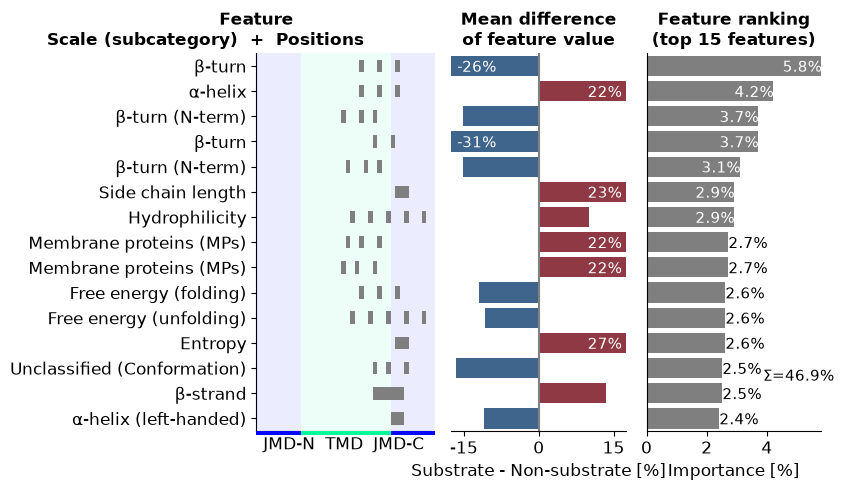

In [4]:
import matplotlib.pyplot as plt

# Key figure: the top determinants the fitted classifier relies on.
# Left subplot = group difference (mean_dif); gray bars = group-level feat_importance.
cpp_plot = aa.CPPPlot(df_scales=None, df_cat=None, jmd_n_len=10, jmd_c_len=10,
                      accept_gaps=False, verbose=False)
fig, axes = cpp_plot.ranking(df_feat=df_feat, shap_plot=False, col_dif="mean_dif",
                             col_imp="feat_importance", rank=True, n_top=15,
                             figsize=None, tmd_len=20, tmd_jmd_space=2,
                             tmd_color="mediumspringgreen", jmd_color="blue",
                             tmd_jmd_alpha=0.075, name_test="Substrate",
                             name_ref="Non-substrate", fontsize_titles=12,
                             fontsize_labels=12, fontsize_annotations=11,
                             xlim_dif=(-17.5, 17.5), xlim_rank=(0, 4),
                             rank_info_xy=None, sample=None)
plt.tight_layout()
plt.show()

Notice how the top bars are TMD/JMD physicochemical patterns, named `PART-SPLIT-SCALE` determinants, not anonymous weights. In the rendered plot, the left panel shows each feature's `mean_dif` (which way it points: bars to the right sit higher in substrates, bars to the left higher in non-substrates), while the gray `feat_importance` bars on the right show how hard the fitted model leans on each one. Read the two together: bar *height* (gray) tells you *how much* a determinant matters, and `mean_dif` *direction* (left) tells you *which way*.

**Honest evaluation hooks (light).** A figure shows *what* the model leans on; these three quick checks tell you whether it is non-trivial. They are **not** a substitute for validation:

1. **Cross-validated metrics** via `TreeModel.eval` over the fitted feature set (`fit` ran with `use_rfe=False`, so all features are kept).
2. **A trivial baseline**, a majority-class `DummyClassifier`; a real model must beat its ~0.5 balanced accuracy.
3. **Per-protein probabilities** via `TreeModel.predict_proba` (a mean score and its Monte-Carlo std).

**Read these numbers as an optimistic upper bound, not an unbiased estimate.** The CPP signature was mined with `labels` on the *whole* 50-protein dataset, then this CV reuses exactly those globally-selected feature columns, so each fold's features were chosen using proteins that also sit in that fold's test split (feature-selection leakage). It is a sanity check / ceiling, not a generalization estimate, and the figure below measures how much of that ceiling is leakage. Leak-free nested or hold-out evaluation plus shuffled-label controls live in **P10: Validation**.

To actually *reduce* the feature set (recursive feature elimination) rather than keep all features, fit with `TreeModel(...).fit(X, labels, use_rfe=True)` or call `select_features`; `is_selected_` then marks the retained subset.

In [5]:
# Cross-validated performance of the full fitted feature set (use_rfe=False
# keeps all features; is_selected_ is all-True). Optimistic: the CPP features
# were selected on the full dataset, so this is an upper bound, not a clean
# generalization estimate (the next figure measures the size of that bound).
df_eval = tm.eval(X=X,
                  labels=labels,
                  list_is_selected=[tm.is_selected_],
                  convert_1d_to_2d=False,
                  names_feature_selections=None,
                  n_cv=5,
                  list_metrics=["accuracy", "balanced_accuracy", "f1", "roc_auc"])

# Trivial majority-class baseline for comparison (~0.5 balanced accuracy).
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

baseline_bacc = cross_val_score(
    DummyClassifier(strategy="most_frequent"),
    X, labels, cv=5, scoring="balanced_accuracy").mean()

aa.display_df(df=df_eval.assign(baseline_balanced_accuracy=round(float(baseline_bacc), 3)),
              n_rows=10, show_shape=True)

DataFrame shape: (1, 6)


,name,accuracy,balanced_accuracy,f1,roc_auc,baseline_balanced_accuracy
1,Set 1,0.920000,0.920000,0.925300,0.984000,0.500000


**Scikit-learn native.** The cross-validation above runs a stock `sklearn` estimator straight on `X`, with no adapter and no wrapper. Because `SequenceFeature.feature_matrix` returns a plain numeric matrix `X` (one column per feature), CPP features compose with **any** scikit-learn estimator, `Pipeline`, or cross-validator. For example, to standardise then classify in one object:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([("scaler", StandardScaler()),
                 ("clf", RandomForestClassifier(random_state=42))])
pipe.fit(X, labels)                       # X = SequenceFeature.feature_matrix(...)
```

The same caveat as the light eval above applies: this fixes the feature set selected once up front, so a `cross_val_score` on it scores the **model**, not the **selection**. For a leak-free estimate that reselects features inside each fold, see **P10: Validation**.

In [6]:
# Per-protein predicted probability of being a substrate (requires prior fit).
import pandas as pd

pred, pred_std = tm.predict_proba(X=X)
df_pred = pd.DataFrame({
    "entry": df_seq["entry"].to_list(),
    "label": labels,
    "p_substrate": pred.round(3),
    "p_std": pred_std.round(3),
})
# These are IN-SAMPLE (training) predictions, shown only to demonstrate the
# output shape -- they say nothing about generalization. p_std is the spread
# across the ensemble (all tree models over all rounds), i.e. agreement, NOT
# held-out confidence: a small p_std means the models concur, not that the call
# is correct on unseen data. Score real, unseen proteins to judge generalization.
aa.display_df(df=df_pred.sort_values("p_substrate", ascending=False),
              n_rows=10, show_shape=True)

DataFrame shape: (50, 4)


,entry,label,p_substrate,p_std
33,P09803,1,1.000000,0.000000
34,P19022,1,1.000000,0.000000
30,Q06481,1,0.999000,0.002000
44,Q9ERC8,1,0.999000,0.002000
36,P09603,1,0.992000,0.005000
35,P16070,1,0.991000,0.005000
42,Q63155,1,0.986000,0.004000
46,Q15303,1,0.984000,0.006000
45,P54763,1,0.984000,0.002000
31,P35613,1,0.980000,0.003000


**The hook, shown.** That caveat is measurable, so the next two cells measure it. One set of five stratified folds is fixed, and the same `TreeModel` is scored over those same folds three times, changing only *where* its features come from:

1. **Trivial baseline**: a majority-class `DummyClassifier`, the floor any real model has to clear.
2. **Leak-free**: `CPP.run` is re-mined inside each *training* fold, and the held-out proteins are scored with the ids that fold selected. Because CPP feature ids are dataset-independent strings, one `SequenceFeature.feature_matrix` call builds the training matrix and a second one builds the test matrix from the very same ids.
3. **Optimistic**: the globally mined `X` from the top of this protocol, the same matrix `TreeModel.eval` just scored.

Folds, estimator and `random_state` are held fixed across the three arms, so the distance between the last two is the feature-selection leakage and nothing else.

In [7]:
import numpy as np
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

# One fixed fold structure, shared by all three arms.
y = np.asarray(labels)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = {"Trivial baseline": [], "Leak-free": [], "Optimistic": []}

for train_idx, test_idx in skf.split(X, y):
    # (a) trivial baseline: always predict the majority class of the training fold
    dummy = DummyClassifier(strategy="most_frequent").fit(X[train_idx], y[train_idx])
    scores["Trivial baseline"].append(
        balanced_accuracy_score(y[test_idx], dummy.predict(X[test_idx])))

    # (b) leak-free: re-mine the CPP signature on the TRAINING proteins only, then
    #     score the held-out proteins with that fold's feature ids.
    df_parts_train, df_parts_test = df_parts.iloc[train_idx], df_parts.iloc[test_idx]
    cpp = aa.CPP(df_parts=df_parts_train)
    df_feat_fold = cpp.run(labels=y[train_idx], n_filter=50, n_jobs=1)
    X_train = sf.feature_matrix(features=df_feat_fold["feature"], df_parts=df_parts_train,
                                n_jobs=1)
    X_test = sf.feature_matrix(features=df_feat_fold["feature"], df_parts=df_parts_test,
                               n_jobs=1)
    tm = aa.TreeModel(verbose=False, random_state=42).fit(X=X_train, labels=y[train_idx])
    proba, _ = tm.predict_proba(X=X_test)
    scores["Leak-free"].append(
        balanced_accuracy_score(y[test_idx], (proba >= 0.5).astype(int)))

    # (c) optimistic: the globally mined X, same folds, same estimator
    tm = aa.TreeModel(verbose=False, random_state=42).fit(X=X[train_idx], labels=y[train_idx])
    proba, _ = tm.predict_proba(X=X[test_idx])
    scores["Optimistic"].append(
        balanced_accuracy_score(y[test_idx], (proba >= 0.5).astype(int)))

df_honest = pd.DataFrame({
    "arm": list(scores),
    "balanced_accuracy": [round(float(np.mean(v)), 3) for v in scores.values()],
    "per_fold": [", ".join(f"{s:.2f}" for s in v) for v in scores.values()],
})
aa.display_df(df=df_honest, n_rows=10, show_shape=True)

DataFrame shape: (3, 3)


,arm,balanced_accuracy,per_fold
1,Trivial baseline,0.500000,"0.50, 0.50, 0.50, 0.50, 0.50"
2,Leak-free,0.840000,"0.90, 0.70, 1.00, 0.80, 0.80"
3,Optimistic,0.940000,"1.00, 0.90, 1.00, 1.00, 0.80"


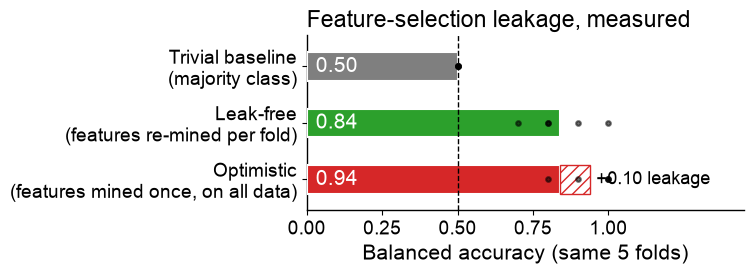

In [8]:
import seaborn as sns

# The three arms over the same folds. The solid part of the optimistic bar is the
# leak-free number; its hatched overhang is what feature-selection leakage adds.
means = {k: float(np.mean(v)) for k, v in scores.items()}
honest, optimistic = means["Leak-free"], means["Optimistic"]
colors = ["#7F7F7F", "tab:green", "tab:red"]
arms = ["Trivial baseline\n(majority class)",
        "Leak-free\n(features re-mined per fold)",
        "Optimistic\n(features mined once, on all data)"]

aa.plot_settings(font_scale=0.85, weight_bold=False, short_ticks=True)
fig, ax = plt.subplots(figsize=(7.8, 3.0))
ypos = np.arange(3)[::-1]
ax.barh(ypos, [means["Trivial baseline"], honest, honest], color=colors, height=0.5,
        edgecolor="white", zorder=3)
ax.barh(ypos[2], optimistic - honest, left=honest, color="white", height=0.5,
        edgecolor=colors[2], hatch="///", linewidth=1.0, zorder=3)
for yp, vals in zip(ypos, scores.values()):
    ax.scatter(vals, np.full(len(vals), yp), color="black", s=11, zorder=5, alpha=0.55)
for yp, m in zip(ypos, means.values()):
    ax.text(0.03, yp, f"{m:.2f}", va="center", ha="left", color="white",
            size=aa.plot_gcfs(), zorder=6)
ax.text(optimistic + 0.02, ypos[2], f"+{optimistic - honest:.2f} leakage",
        va="center", ha="left", size=aa.plot_gcfs() - 2)
ax.axvline(0.5, color="black", ls="--", lw=1, zorder=4)
ax.set_yticks(ypos)
ax.set_yticklabels(arms)
ax.set_ylim(-0.55, 2.55)
ax.set_xlim(0, 1.45)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel("Balanced accuracy (same 5 folds)")
ax.set_title("Feature-selection leakage, measured", size=aa.plot_gcfs() + 1, loc="left")
sns.despine()
plt.tight_layout()
plt.show()

Reading it: both model arms clear the dashed 0.50 baseline by a wide margin, which is the check that actually matters here, so the TMD/JMD physicochemistry is plausibly discriminative. The hatched overhang is the rest of the story: it is balanced accuracy that the globally mined signature was borrowing from proteins sitting in its own test folds, and a protein the pipeline has never seen will not honour it. The black dots are the five per-fold values, and their spread on a 50-protein fixture is the second reason to read any single number as provisional. Note also that the leak-free arm is still not a clean generalization estimate: only the *features* were re-mined per fold, while the dataset, the parts and the split settings were fixed once up front. Doing this properly, with a shuffled-label control that proves the pipeline cannot learn noise, is **P10: Validation**.

**How to interpret.**

| Output | Non-expert reading |
| --- | --- |
| `balanced_accuracy` clearly above the ~0.5 baseline | the selected TMD/JMD physicochemistry is *plausibly* discriminative, confirm with leak-free validation in **P10: Validation** (this light CV is an optimistic upper bound) |
| high `roc_auc` | the model ranks substrates above non-substrates reliably |
| high `feat_importance` (tall gray bar in the ranking plot) | the determinant the model **leans on most** for the call |
| sign of `mean_dif` for that feature | **direction** of the effect (positive = property higher in substrates) |
| `p_substrate` near 1 (or 0) | a substrate (or non-substrate) call; in-sample here, so judge confidence only on unseen proteins |
| large `p_std` | an unstable prediction (the ensemble models disagree) |

`feat_importance` is **unsigned** (magnitude of influence only). Always pair it with `mean_dif` from the CPP **signature** to recover the biological direction, e.g. *higher side-chain volume in the TMD core* rather than just *side-chain volume matters*.

**Key takeaways**

- The classifier is a **glass box**: each input is a named `PART-SPLIT-SCALE` determinant, so a tall `feat_importance` bar points at a concrete physicochemical property at a concrete sequence location, read with the sign of `mean_dif` for direction.
- A model is only worth interpreting once it **clearly beats the ~0.5 baseline**; here balanced accuracy sits well above it.
- These numbers are an **optimistic ceiling**, and the leakage figure above puts a number on it: re-mining the signature inside each fold costs balanced accuracy, and what it costs is exactly what a globally mined signature was quietly borrowing from the test folds. Treat the result as "plausibly discriminative" and defer real trust to **P10: Validation**.

**Common mistakes.**

- **`CPP(df_seq=...)` / `CPP().run(df_seq, labels)`**: `CPP` takes `df_parts`; build them with `SequenceFeature.get_df_parts` first.
- **Skipping the feature matrix**: `TreeModel.fit` needs numeric `X` from `SequenceFeature.feature_matrix`, not `df_feat` or `df_seq`.
- **Reading `feat_importance` as signed**: it is magnitude only; combine with `mean_dif` for direction.
- **Calling `predict_proba` or `add_feat_importance` before `fit`**: both rely on attributes set during `.fit`.
- **Mistaking light eval for validation**: the CV row and baseline here are sanity checks; rigorous trust-building is **P10: Validation**.
- **Mis-using `dPULearn`**: it expects labels **1 (positive) and 2 (unlabelled)**, not 0/1, and `n_unl_to_neg` must be **>= 1 and must not exceed** the number of unlabelled samples.

**PU note: when confirmed negatives are scarce.** Real GSEC datasets often have **confirmed substrates (positives, label 1)** but few confirmed non-substrates; the rest are **unlabelled (label 2)**. You cannot train a clean binary classifier on positives-plus-unlabelled directly.

`dPULearn` (core, no pro dependency) solves the first half: from the unlabelled pool it identifies **reliable negatives (label 0)**, the proteins most dissimilar from the positives in CPP feature space, which you can then feed to the classifier above. See the dPULearn tutorial for the method details.

Because CPP feature identifiers are **dataset-independent strings**, the *same* `df_feat["feature"]` builds the feature matrix for the PU proteins. We demonstrate on the bundled `DOM_GSEC_PU` dataset, then visualize the carve with the canonical **dPULearn PCA**: positives, the newly carved reliable negatives, and the still-unlabelled pool laid out in the first two principal components of CPP feature space.

In [9]:
# Positives (1) + unlabelled (2): n=20 -> 20 positives and 20 unlabelled.
df_seq_pu = aa.load_dataset(name="DOM_GSEC_PU", n=20, random=False,
                            non_canonical_aa="remove", min_len=None, max_len=None,
                            aa_window_size=9, verbose=False)
labels_pu = df_seq_pu["label"].to_list()

# Reuse the SAME CPP feature ids to build X for the PU proteins.
df_parts_pu = sf.get_df_parts(df_seq=df_seq_pu, list_parts=None, all_parts=False,
                              jmd_n_len=10, jmd_c_len=10, tmd_len=None,
                              remove_entries_with_gaps=False,
                              replace_non_canonical_aa=False)
X_pu = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts_pu,
                         df_scales=None, accept_gaps=False, n_jobs=1, batch=False,
                         df_seq=None, df_parts_kws=None)

# Carve reliable negatives (0) from the unlabelled pool (2).
# n_unl_to_neg must be >= 1 and must not exceed the number of unlabelled samples (<= 20 here).
# n_components=5 keeps several leading PCs so the carve is visualizable as a PC1-vs-PC2 PCA.
dpul = aa.dPULearn(model_kwargs=None, verbose=False, random_state=42)
dpul = dpul.fit(X=X_pu, labels=labels_pu, X_pos=None, X_unlabeled=None, label_pos=1,
                label_unl=2, label_neg=None, n_neg=None, n_unl_to_neg=10, metric=None,
                n_components=5)

# labels_: 1 = positive, 0 = newly identified reliable negative, 2 = still unlabelled.
df_carve = pd.DataFrame({
    "label": [1, 0, 2],
    "meaning": ["positive", "carved reliable negative", "still unlabelled"],
    "n": [int((dpul.labels_ == v).sum()) for v in (1, 0, 2)],
})
aa.display_df(df=df_carve, n_rows=10, show_shape=True)

DataFrame shape: (3, 3)


,label,meaning,n
1,1,positive,20
2,0,carved reliable negative,10
3,2,still unlabelled,10


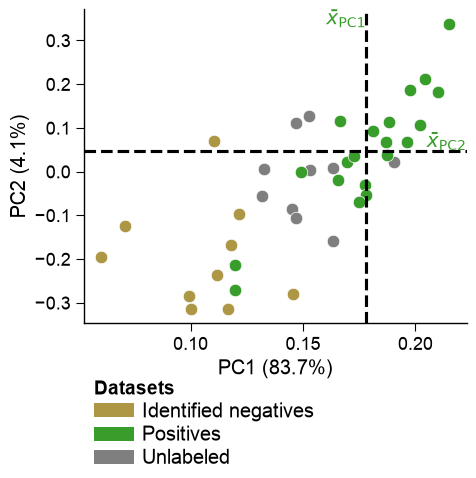

In [10]:
# Headline figure: the dPULearn PCA. The PU proteins are projected into the
# first two principal components of CPP feature space. Dashed lines mark the
# positive-class mean per PC; the unlabelled points (2) furthest from it are
# carved as reliable negatives (0), which then feed the classifier above.
df_pu = dpul.df_pu_
labels_carved = dpul.labels_

aa.plot_settings(font_scale=0.8)
dpul_plot = aa.dPULearnPlot()
dpul_plot.pca(df_pu=df_pu, labels=labels_carved, figsize=(5, 5), pc_x=1, pc_y=2,
              show_pos_mean_x=True, show_pos_mean_y=True, colors=None, names=None,
              df_pu_add=None, names_add=None, colors_add=None, legend=True,
              legend_y=-0.15, kwargs_scatterplot=None)
plt.tight_layout()
plt.show()

**Beyond binary: multi-class and regression.** CPP never becomes multi-class or regression-aware. Instead you decompose the harder task into a set of binary contrasts with the `SequenceFeature.get_labels_*` helpers, then loop the same `CPP.run` (and, if you want a predictor, the same `TreeModel`) over them. The contrast you build, not a change to CPP, is what adapts the workflow. We reuse the `df_parts` and feature matrix `X` from the binary run above. Each helper builds its own set of binary contrasts, and the figure closing this section draws all of them on one axis, so the three settings are comparable at a glance.

**Multi-class (build the classes).** `DOM_GSEC` is binary, so we manufacture a three-class problem the way you would split a heterogeneous group into sub-types: cluster the **substrates** into two physicochemical groups with `AAclust` (clustered on the CPP feature matrix `X`, so the sub-types are physicochemically meaningful), keeping the **non-substrates** as the third class.

In [11]:
import numpy as np
from sklearn.cluster import KMeans

# Cluster substrates (label 1) into two sub-types on the CPP feature matrix;
# non-substrates (label 0) stay as the third class.
sub_mask = np.array(labels) == 1
aac = aa.AAclust(model_class=KMeans, model_kwargs=None, verbose=False, random_state=42)
aac.fit(X=X[sub_mask], n_clusters=2, on_center=True, min_th=0.3, merge=True,
        metric="euclidean", names=None)
sub_clusters = np.asarray(aac.labels_)          # 0 / 1 per substrate

multiclass = np.zeros(len(labels), dtype=int)   # class 0 = non-substrates
multiclass[sub_mask] = sub_clusters + 1         # class 1, 2 = substrate sub-types

df_classes = pd.DataFrame({
    "class": [0, 1, 2],
    "meaning": ["non-substrate", "substrate sub-type A", "substrate sub-type B"],
    "n": [int((multiclass == c).sum()) for c in (0, 1, 2)],
})
aa.display_df(df=df_classes, n_rows=10, show_shape=True)

DataFrame shape: (3, 3)


,class,meaning,n
1,0,non-substrate,25
2,1,substrate sub-type A,15
3,2,substrate sub-type B,10


**One-vs-rest (OvR).** `get_labels_ovr` turns the three classes into three full-length binary arrays: each class in turn is the test group, everything else the reference. No samples are dropped, so all three reuse the same `df_parts`; loop `CPP.run` once per class to read each class's own signature.

In [12]:
# One-vs-rest: each class becomes the test group (1) vs all others (0).
dict_ovr = sf.get_labels_ovr(labels=multiclass, label_test=1, label_ref=0)
rows = []
for cls, y_ovr in dict_ovr.items():
    cpp = aa.CPP(df_parts=df_parts)
    df_f = cpp.run(labels=y_ovr, n_filter=10, n_jobs=1)
    top = df_f.iloc[0]
    rows.append({"class": int(cls), "n_test": int((y_ovr == 1).sum()),
                 "top_feature": top["feature"], "top_abs_auc": round(float(top["abs_auc"]), 3)})
aa.display_df(df=pd.DataFrame(rows), n_rows=10, show_shape=True)

DataFrame shape: (3, 4)


,class,n_test,top_feature,top_abs_auc
1,0,25,"TMD_C_JMD_C-Pat...,12)-CRAJ730103",0.426000
2,1,15,"TMD_C_JMD_C-Seg...6,9)-VHEG790101",0.476000
3,2,10,"TMD_C_JMD_C-Pat...,15)-OOBM850101",0.416000


**One-vs-one (OvO).** `get_labels_ovo` compares each **pair** of classes, discarding the others. Because samples are dropped, it returns per pair the row-matched `df_parts` copy alongside the labels (pass `dict_num_parts` instead for `CPP.run_num`), so each pair feeds `CPP.run` directly with no manual masking.

In [13]:
# One-vs-one: each class pair, other classes discarded. The helper subsets
# df_parts for us and returns the row-matched copy.
res_ovo = sf.get_labels_ovo(labels=multiclass, df_parts=df_parts, dict_num_parts=None,
                            label_test=1, label_ref=0)
rows = []
for (a, b), (df_pair, _, y_pair) in res_ovo.items():
    cpp = aa.CPP(df_parts=df_pair)
    df_f = cpp.run(labels=y_pair, n_filter=10, n_jobs=1)
    top = df_f.iloc[0]
    rows.append({"pair": f"{a} vs {b}", "n": int(len(df_pair)),
                 "top_feature": top["feature"], "top_abs_auc": round(float(top["abs_auc"]), 3)})
aa.display_df(df=pd.DataFrame(rows), n_rows=10, show_shape=True)

DataFrame shape: (3, 4)


,pair,n,top_feature,top_abs_auc
1,0 vs 1,40,"TMD_C_JMD_C-Seg...3,4)-EISD860102",0.484000
2,0 vs 2,35,"TMD_C_JMD_C-Pat...,14)-TANS770110",0.472000
3,1 vs 2,25,"TMD_C_JMD_C-Seg...4,6)-RACS820101",0.500000


**Regression (continuous target).** For a continuous score CPP still needs two groups, so we cut the score into a contrast. Here we attach a **random cleavage-efficiency** value to each substrate (replace with real measurements in practice) and turn it into labels two ways: `get_labels_quantile` for a single high-vs-low split, and `get_labels_tiered` for a fixed high-efficiency positive set compared against progressively stricter low-efficiency negatives (the middle band dropped per tier, with the row-matched `df_parts` returned).

In [14]:
# Continuous target: random cleavage efficiency per substrate (placeholder).
rng = np.random.default_rng(42)
df_parts_sub = df_parts[sub_mask]
efficiency = rng.uniform(0.0, 1.0, size=int(sub_mask.sum()))

# Single quantile cut: high (>= median) vs low efficiency (no samples dropped).
y_q = sf.get_labels_quantile(targets=efficiency, q=0.5, label_test=1, label_ref=0)
cpp = aa.CPP(df_parts=df_parts_sub)
df_feat_q = cpp.run(labels=y_q, n_filter=15, n_jobs=1)

# Tiered: fixed high-efficiency positives vs progressively stricter negatives.
res_tier = sf.get_labels_tiered(targets=efficiency, q_pos=0.7, list_q_neg=[0.5, 0.3],
                                df_parts=df_parts_sub, dict_num_parts=None,
                                label_test=1, label_ref=0)
rows = [{"contrast": "quantile q=0.5", "n_samples": int(len(df_parts_sub)),
         "top_feature": df_feat_q.iloc[0]["feature"]}]
for q_neg, (df_tier, _, y_tier) in res_tier.items():
    cpp = aa.CPP(df_parts=df_tier)
    df_f = cpp.run(labels=y_tier, n_filter=10, n_jobs=1)
    rows.append({"contrast": f"tiered q_neg={q_neg}", "n_samples": int(len(df_tier)),
                 "top_feature": df_f.iloc[0]["feature"]})
aa.display_df(df=pd.DataFrame(rows), n_rows=10, show_shape=True)

DataFrame shape: (3, 3)


,contrast,n_samples,top_feature
1,quantile q=0.5,25,"TMD-PeriodicPat...4,2)-NAKH900113"
2,tiered q_neg=0.5,21,"TMD-Pattern(C,3...,13)-JANJ790101"
3,tiered q_neg=0.3,16,"TMD-Pattern(N,8...,15)-QIAN880138"


**The three settings in one picture.** Binary, multi-class and regression look like three different tasks, but by the time they reach `CPP.run` they are the same object: one `labels` array holding a **test group** and a **reference group**. What the three settings really decide is which proteins land in which group, and which are dropped from the contrast altogether. The figure below draws exactly that, one bar per contrast built in this section, so the settings can be compared as a family instead of read one cell at a time.

In [15]:
# Collect the composition of every contrast built above: how many proteins are
# the test group, the reference group, and how many the helper dropped.
n_total, n_sub = len(labels), len(df_parts_sub)
name_bin = "Binary: the labels as given"
name_mc = "Multi-class: one label per class"
name_reg = "Regression: a cut through a continuous score"

rows = [(name_bin, "substrate vs non-substrate",
         int((y == 1).sum()), int((y == 0).sum()), 0)]
for cls, y_ovr in dict_ovr.items():
    rows.append((name_mc, f"OvR: class {cls}", int((y_ovr == 1).sum()),
                 int((y_ovr == 0).sum()), n_total - len(y_ovr)))
for (a, b), (df_pair, _, y_pair) in res_ovo.items():
    rows.append((name_mc, f"OvO: {a} vs {b}", int((y_pair == 1).sum()),
                 int((y_pair == 0).sum()), n_total - len(y_pair)))
rows.append((name_reg, "quantile q=0.5", int((y_q == 1).sum()),
             int((y_q == 0).sum()), n_sub - len(y_q)))
for q_neg, (df_tier, _, y_tier) in res_tier.items():
    rows.append((name_reg, f"tiered q_neg={q_neg}", int((y_tier == 1).sum()),
                 int((y_tier == 0).sum()), n_sub - len(y_tier)))

df_contrasts = pd.DataFrame(rows, columns=["setting", "contrast", "n_test", "n_ref",
                                           "n_dropped"])
aa.display_df(df=df_contrasts, n_rows=10, show_shape=True)

DataFrame shape: (10, 5)


,setting,contrast,n_test,n_ref,n_dropped
1,Binary: the labels as given,substrate vs non-substrate,25,25,0
2,Multi-class: on...label per class,OvR: class 0,25,25,0
3,Multi-class: on...label per class,OvR: class 1,15,35,0
4,Multi-class: on...label per class,OvR: class 2,10,40,0
5,Multi-class: on...label per class,OvO: 0 vs 1,25,15,10
6,Multi-class: on...label per class,OvO: 0 vs 2,25,10,15
7,Multi-class: on...label per class,OvO: 1 vs 2,15,10,25
8,Regression: a c...ontinuous score,quantile q=0.5,13,12,0
9,Regression: a c...ontinuous score,tiered q_neg=0.5,8,13,4
10,Regression: a c...ontinuous score,tiered q_neg=0.3,8,8,9


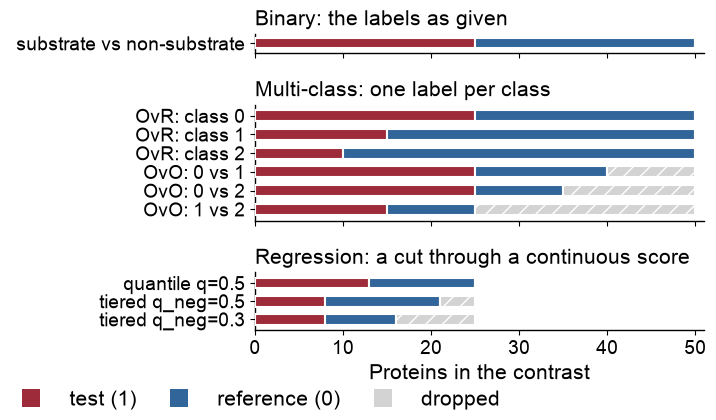

In [16]:
# One bar per contrast: test group, reference group, and the proteins dropped.
# The regression rows are shorter because they are drawn from the 25 substrates only.
dict_color = aa.plot_get_cdict(name="DICT_COLOR")
c_test, c_ref, c_drop = dict_color["FEAT_POS"], dict_color["FEAT_NEG"], "lightgray"
settings = df_contrasts["setting"].unique().tolist()

aa.plot_settings(font_scale=0.85, weight_bold=False, short_ticks=True)
fig, axes = plt.subplots(3, 1, figsize=(7.4, 4.8), sharex=True,
                         gridspec_kw={"height_ratios":
                                      [int((df_contrasts["setting"] == s).sum())
                                       for s in settings]})
for ax, setting in zip(axes, settings):
    df_s = df_contrasts[df_contrasts["setting"] == setting]
    ypos = np.arange(len(df_s))[::-1]
    n_test = df_s["n_test"].to_numpy()
    n_ref = df_s["n_ref"].to_numpy()
    n_drop = df_s["n_dropped"].to_numpy()
    ax.barh(ypos, n_test, color=c_test, height=0.6, edgecolor="white", zorder=3)
    ax.barh(ypos, n_ref, left=n_test, color=c_ref, height=0.6, edgecolor="white", zorder=3)
    ax.barh(ypos, n_drop, left=n_test + n_ref, color=c_drop, height=0.6,
            edgecolor="white", hatch="//", zorder=3)
    ax.set_yticks(ypos)
    ax.set_yticklabels(df_s["contrast"].to_list())
    ax.set_ylim(-0.6, len(df_s) - 0.4)
    ax.set_title(setting, size=aa.plot_gcfs(), loc="left")
    ax.set_xlim(0, 51)
axes[-1].set_xlabel("Proteins in the contrast")
sns.despine()
aa.plot_legend(ax=axes[-1], dict_color={"test (1)": c_test, "reference (0)": c_ref,
                                        "dropped": c_drop},
               n_cols=3, loc="upper center", y=-0.85, marker="s", marker_size=13)
plt.tight_layout()
plt.show()

Reading it: the binary row is the whole dataset, 25 against 25. One-vs-rest keeps all 50 proteins and only moves the boundary, so class 2 arrives at CPP as a 10-versus-40 contrast that is harder than class 0's balanced one. One-vs-one and the two tiered contrasts carry a grey block: those proteins are dropped, which is precisely why both helpers hand back the row-matched `df_parts` instead of leaving you to mask it by hand. The regression bars are shorter than the multi-class bars because they are drawn from the 25 substrates only, the subset the continuous score is defined on.

Each contrast yields its own CPP **signature** that you read exactly as the binary one (and can feed to `TreeModel` for a per-contrast predictor). **Key takeaways:** CPP stays binary, and the figure above is that claim in one picture: whichever setting you pick, what reaches `CPP.run` is a single test-versus-reference split. `get_labels_*` turns a harder task into those binary contrasts. OvR and quantile keep all samples (shared `df_parts`); OvO and tiered drop samples (the grey blocks) and hand back the matching `df_parts` subset, so there is never a mask to apply by hand.

**Next step.** To explain a single prediction down to per-sample, single-residue contributions (`ShapModel`, sample-level `CPPPlot.feature_map`), continue to **P9: Interpretability**; for leak-free evaluation of any of these contrasts, see **P10: Validation**.